# Lesson 1: the native `LeRobotDataset`

Goal: understand what a LeRobot dataset *is* from the Python side, well enough to feed one to a trained policy later in the series.

You will be able to:

1. Load a dataset and read its metadata (fps, features, tasks)
2. Index a single frame and know what every tensor in it means
3. Slice an episode and plot its actions
4. Use `delta_timestamps` to stack past observations and future actions (what policies actually consume)
5. Build a `DataLoader` batch shaped the way a policy expects

Dataset: `lerobot/aloha_sim_insertion_human` (50 simulated episodes, one camera, 14-dim state/action, 50 fps). Env: `fo_lerobot`.

## 1. Load the dataset

`LeRobotDataset(repo_id)` is a `torch.utils.data.Dataset`. On first call it downloads from the Hub; after that it reads from cache.

Watch the cache location: lerobot uses **its own** root `~/.cache/huggingface/lerobot/`, not the normal `~/.cache/huggingface/hub/`. That is why `ds.root` below is not where `hf download` would put things.

In [1]:
import logging
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"       # no download widgets cluttering the notebook
logging.getLogger("lerobot").setLevel(logging.ERROR)  # silence the harmless 'files_size_in_mb' warning

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from lerobot.datasets.lerobot_dataset import LeRobotDataset

REPO_ID = "lerobot/aloha_sim_insertion_human"
ds = LeRobotDataset(REPO_ID)

print("root:        ", ds.root)
print("num_episodes:", ds.num_episodes)
print("num_frames:  ", ds.num_frames)
print("fps:         ", ds.fps)

root:         /home/harpreet/.cache/huggingface/lerobot/hub/datasets--lerobot--aloha_sim_insertion_human/snapshots/cc571a3c661df81b566dbfde3d5c1e85fcdf7884
num_episodes: 50
num_frames:   25000
fps:          50


## 2. Metadata: `ds.meta`

`ds.meta` is a `LeRobotDatasetMetadata`. It is cheap (no video decoding) and holds everything from `meta/info.json` plus the episode and task tables.

The **features** table is the schema. Every key is one column of every frame. Three kinds matter:

- `observation.images.*` — camera streams, dtype `video`, stored as mp4
- `observation.state` — proprioception (joint positions etc.), a float vector
- `action` — what the robot was commanded to do at that frame, same shape as state here

Everything else (`episode_index`, `frame_index`, `timestamp`, `index`, `task_index`, `next.done`) is bookkeeping.

The mental model: **one flat table, one row per frame, one column per feature.** Episodes are just contiguous row ranges. The camera column is special: its pixels live in mp4 files, and the table only knows which video and which timestamp each row corresponds to.

![the dataset as one flat table](figures/01_dataset_table.png)

In [2]:
meta = ds.meta

print("codebase_version:", meta.info.codebase_version)
print("robot_type:      ", meta.robot_type)
print("camera_keys:     ", meta.camera_keys)
print()
print(f"{'feature':28s} {'dtype':8s} shape")
for name, spec in meta.features.items():
    print(f"{name:28s} {spec['dtype']:8s} {spec['shape']}")

print()
print("tasks table:")
print(meta.tasks)

codebase_version: v3.0
robot_type:       aloha
camera_keys:      ['observation.images.top']

feature                      dtype    shape
observation.images.top       video    (480, 640, 3)
observation.state            float32  (14,)
action                       float32  (14,)
episode_index                int64    (1,)
frame_index                  int64    (1,)
timestamp                    float32  (1,)
next.done                    bool     (1,)
index                        int64    (1,)
task_index                   int64    (1,)

tasks table:
                                 task_index
task                                       
Insert the peg into the socket.           0


## 3. What is on disk (one look, then we stay in Python)

v3.0 layout, three folders:

- `meta/` — `info.json` (schema), `stats.json` (normalization), `tasks.parquet`, `episodes/` (episode boundaries)
- `data/` — parquet files holding every non-video column, many episodes per file
- `videos/<camera_key>/` — mp4 files, many episodes concatenated per file; the episodes table stores the `from_timestamp`/`to_timestamp` to seek into them

The class hides all of this. The only reason to know it: when something fails to load, this is where you look.

In [3]:
for dirpath, _, filenames in os.walk(ds.root):
    depth = str(dirpath)[len(str(ds.root)):].count(os.sep)
    if depth > 3:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath)}/")
    for f in sorted(filenames)[:3]:
        print(f"{indent}  {f}")
    if len(filenames) > 3:
        print(f"{indent}  ... ({len(filenames)} files)")

cc571a3c661df81b566dbfde3d5c1e85fcdf7884/
  .gitattributes
  README.md
  meta/
    info.json
    stats.json
    tasks.parquet
    episodes/
      chunk-000/
        file-000.parquet
  videos/
    observation.images.top/
      chunk-000/
        file-000.mp4
  data/
    chunk-000/
      file-000.parquet
      file-001.parquet
      file-002.parquet
      ... (4 files)


## 4. One frame: `ds[i]`

Indexing returns a `dict` with one entry per feature, plus `task` (the natural-language instruction as a string). Image tensors come back **decoded from video**, as `float32`, channels-first `(C, H, W)`, scaled to `[0, 1]`. That decode is the expensive part of every `__getitem__`.

Scalar bookkeeping fields are 0-d tensors.

`ds[i]` is **one row of the table**, with the video column decoded into pixels:

![one frame as a dict of tensors](figures/02_one_frame.png)

State and action share the same 14 slots. Slot 6 and slot 13 are the grippers; the other twelve are arm joints, six per arm.

observation.images.top       (3, 480, 640)          torch.float32
observation.state            (14,)                  torch.float32
action                       (14,)                  torch.float32
episode_index                ()                     torch.int64
frame_index                  ()                     torch.int64
timestamp                    ()                     torch.float32
next.done                    ()                     torch.bool
index                        ()                     torch.int64
task_index                   ()                     torch.int64
task                         'Insert the peg into the socket.'

image min/max: 0.0 1.0


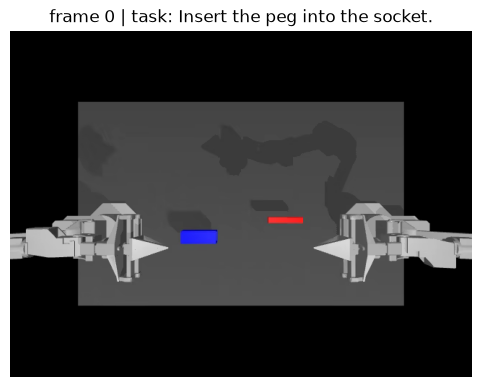

In [4]:
def describe(d):
    """Print one line per entry of a frame or batch dict: shape and dtype, or the value."""
    for k, v in d.items():
        if hasattr(v, "shape"):
            print(f"{k:28s} {str(tuple(v.shape)):22s} {v.dtype}")
        elif isinstance(v, list):
            print(f"{k:28s} {type(v).__name__} of {len(v)} -> {v[0]!r}")
        else:
            print(f"{k:28s} {v!r}")

frame = ds[0]
describe(frame)

img = frame["observation.images.top"]
print()
print("image min/max:", img.min().item(), img.max().item())

plt.figure(figsize=(6, 4.5))
plt.imshow(img.permute(1, 2, 0))  # CHW -> HWC for matplotlib
plt.title(f"frame 0 | task: {frame['task']}")
plt.axis("off")
plt.show()

## 5. Episodes

Frames are stored flat: index `0..num_frames-1`. An episode is a contiguous range. `ds.meta.episodes[i]` gives `dataset_from_index` / `dataset_to_index` for episode `i`.

Below: pull every frame of episode 0 **from the parquet table only** (`ds.hf_dataset`, no video decode, so it is fast) and plot the 14 action dimensions against time. This is what the policy will be asked to predict.

Slicing rows `0:500` of the `action` column gives a `(500, 14)` matrix. Time runs down, joints run across. Each **column** of that matrix is one curve in the plot (left panel below: the matrix as a heatmap; right panel: the same numbers as lines):

![episode 0 actions as a (500, 14) matrix and as 14 lines](figures/03_episode_matrix.png)

The code below draws the right-hand panel itself, split into left-arm and right-arm halves.

episode 0: {'episode_index': 0, 'dataset_from_index': 0, 'dataset_to_index': 500, 'length': 500, 'tasks': ['Insert the peg into the socket.']}
actions: (500, 14)  duration: 9.98 s


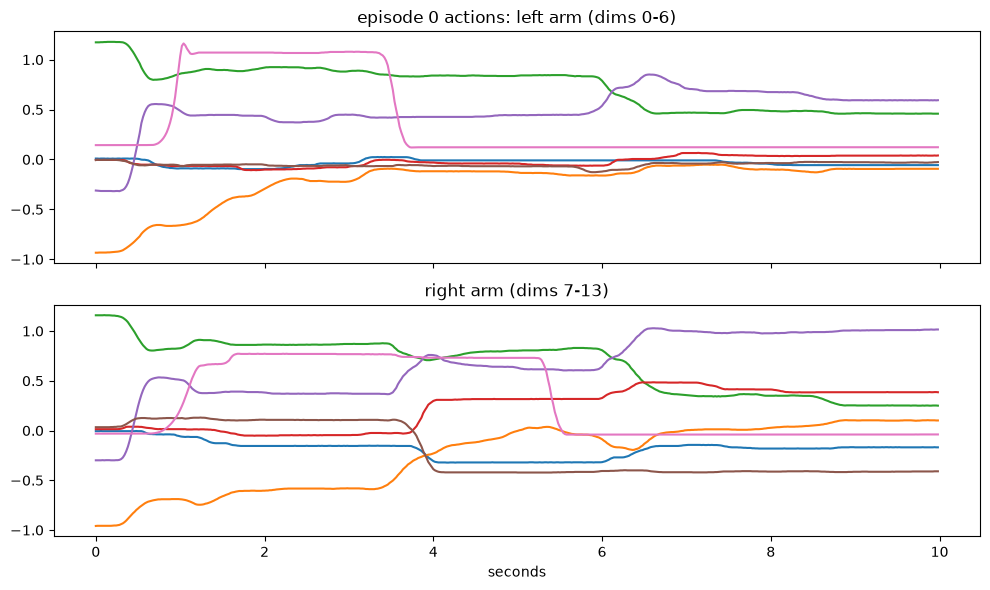

In [5]:
ep = ds.meta.episodes[0]
start, stop = ep["dataset_from_index"], ep["dataset_to_index"]
print("episode 0:", {k: ep[k] for k in ["episode_index", "dataset_from_index", "dataset_to_index", "length", "tasks"]})

# hf_dataset holds the non-video columns; select() is a cheap row slice.
# Columns come back lazy (a datasets.Column), so list() them before stacking.
rows = ds.hf_dataset.select(range(start, stop))
actions = torch.stack(list(rows["action"]))     # (T, 14)
t = torch.stack(list(rows["timestamp"]))        # (T,)
print("actions:", tuple(actions.shape), " duration:", round(t[-1].item(), 2), "s")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, actions[:, :7]);  axes[0].set_title("episode 0 actions: left arm (dims 0-6)")
axes[1].plot(t, actions[:, 7:]);  axes[1].set_title("right arm (dims 7-13)")
axes[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 6. Stats: `ds.meta.stats`

Per-feature `min / max / mean / std / count`, computed over the whole dataset. Policies normalize `observation.state` and `action` with these (subtract mean, divide by std) before the network sees them, and un-normalize predicted actions on the way out.

When you load a pretrained policy, **its** stats travel with the checkpoint. A policy trained on a different robot carries stats for a different state/action space, and normalizing this dataset with them produces garbage without raising an error. Lesson 4 shows how to check for this before running anything.

In [6]:
stats = ds.meta.stats
print("features with stats:", list(stats.keys()))
print()
for key in ["observation.state", "action"]:
    s = stats[key]
    print(key)
    print("  mean:", [round(float(x), 3) for x in s["mean"]])
    print("  std: ", [round(float(x), 3) for x in s["std"]])
print()
print("image stats are per-channel, shape:", stats["observation.images.top"]["mean"].shape)

features with stats: ['episode_index', 'action', 'timestamp', 'next.done', 'observation.state', 'frame_index', 'index', 'task_index', 'observation.images.top']

observation.state
  mean: [0.008, -0.187, 0.738, -0.007, 0.441, -0.004, 0.621, -0.099, -0.215, 0.649, 0.189, 0.615, -0.143, 0.416]
  std:  [0.109, 0.224, 0.203, 0.103, 0.226, 0.139, 0.192, 0.142, 0.317, 0.285, 0.185, 0.304, 0.288, 0.257]
action
  mean: [0.008, -0.182, 0.732, -0.007, 0.436, -0.003, 0.279, -0.1, -0.206, 0.644, 0.202, 0.611, -0.144, 0.255]
  std:  [0.11, 0.216, 0.202, 0.107, 0.22, 0.139, 0.271, 0.142, 0.313, 0.286, 0.192, 0.3, 0.288, 0.35]

image stats are per-channel, shape: (3, 1, 1)


## 7. `delta_timestamps`: the concept policies are built on

A policy rarely wants a single frame. It wants, at time `t`:

- a short **history** of observations (e.g. `t-1/fps` and `t`)
- a **chunk** of future actions to predict (e.g. `t, t+1/fps, ..., t+9/fps`)

`delta_timestamps` is a dict `{feature_key: [offsets in seconds]}`. Pass it at construction and `ds[i]` returns those features with an extra leading time axis.

Picture the episode as a timeline of rows. For frame `t`, each offset list picks rows relative to `t`, and the picked rows are **stacked along a new leading axis**:

![delta_timestamps picks rows relative to t and stacks them](figures/04_delta_timestamps.png)

Near episode boundaries some offsets fall outside the episode. LeRobot clamps them to the nearest valid frame and gives you a boolean mask `<key>_is_pad` so the loss can ignore them. At the last frame of the episode (row 499) only offset 0 is real:

![padding at the end of the episode](figures/05_padding.png)

The cell below prints exactly this mask for a mid-episode frame (all `False`) and for the last frame (9 `True`).

In [7]:
fps = ds.fps
delta_timestamps = {
    "observation.images.top": [-1 / fps, 0.0],        # previous frame + current frame
    "observation.state":      [-1 / fps, 0.0],
    "action":                 [i / fps for i in range(10)],  # current + 9 future actions
}

ds_chunked = LeRobotDataset(REPO_ID, episodes=[0], delta_timestamps=delta_timestamps)

mid = ds_chunked[100]
print("mid-episode frame:")
print("  image  ", tuple(mid["observation.images.top"].shape), " <- (time, C, H, W)")
print("  state  ", tuple(mid["observation.state"].shape))
print("  action ", tuple(mid["action"].shape), " <- (time, 14)")
print("  action_is_pad", mid["action_is_pad"].tolist())

last = ds_chunked[ds_chunked.num_frames - 1]
print()
print("last frame of the episode:")
print("  action_is_pad", last["action_is_pad"].tolist())

mid-episode frame:
  image   (2, 3, 480, 640)  <- (time, C, H, W)
  state   (2, 14)
  action  (10, 14)  <- (time, 14)
  action_is_pad [False, False, False, False, False, False, False, False, False, False]

last frame of the episode:
  action_is_pad [False, True, True, True, True, True, True, True, True, True]


## 8. A batch, the way a policy sees it

Because `LeRobotDataset` is a `torch.utils.data.Dataset`, a plain `DataLoader` collates frames into a batch: every tensor gains a leading batch dimension, `task` becomes a list of strings.

Batching is one more stack, this time across **different frames** instead of different time offsets. With `batch_size=8` the loader picks 8 random frames, calls `ds_chunked[i]` on each, and stacks matching keys:

![DataLoader stacks 8 frames into a batch](figures/06_batch.png)

Read any batch shape as `(batch, time, ...feature...)`: `action (8, 10, 14)` is 8 frames, each with 10 future timesteps, each a 14-joint command.

This dict is the contract. A policy declares the keys and shapes it expects in its config; Lesson 4 loads one and checks it against exactly this batch.

In [8]:
loader = DataLoader(ds_chunked, batch_size=8, shuffle=True, num_workers=0)
batch = next(iter(loader))
describe(batch)

observation.images.top       (8, 2, 3, 480, 640)    torch.float32
observation.state            (8, 2, 14)             torch.float32
action                       (8, 10, 14)            torch.float32
episode_index                (8,)                   torch.int64
frame_index                  (8,)                   torch.int64
timestamp                    (8,)                   torch.float32
next.done                    (8,)                   torch.bool
index                        (8,)                   torch.int64
task_index                   (8,)                   torch.int64
observation.images.top_is_pad (8, 2)                 torch.bool
observation.state_is_pad     (8, 2)                 torch.bool
action_is_pad                (8, 10)                torch.bool
task                         list of 8 -> 'Insert the peg into the socket.'


## Recap

The shapes, end to end. Every arrow is one thing you did in this notebook:

![shapes end to end](figures/07_shape_flow.png)

- `LeRobotDataset` = flat table of frames + mp4 cameras + metadata; episodes are index ranges
- `ds.meta.features` is the schema; `ds.meta.stats` is the normalization
- `ds[i]` decodes video, so use `ds.hf_dataset` when you only need state/action
- `delta_timestamps` turns single frames into (history, action-chunk) samples with `*_is_pad` masks
- `DataLoader(ds)` produces the dict a policy consumes

Next (Lesson 2): the same dataset as a FiftyOne dataset, where one sample is one episode.